This notebooks evaluates our novel heuristic alpha computation approach based on the dataset metadata

For convinience the code is given below:

In [2]:
def compute_alpha_from_metadata(num_docs,num_queries,num_qrels,rel_counts):
    avg_rels = num_qrels / max(1,num_queries)
    doc_factor = np.clip(np.log10(num_docs)/6,0,1)
    query_factor = np.clip(num_queries/10000,0,1)
    alpha_bm25_bias = 1.0 - 0.5*query_factor - 0.3*doc_factor
    alpha_dense_bias = 1.0 - np.clip(avg_rels/100,0,1)
    alpha = np.clip(0.5*alpha_bm25_bias + 0.5*alpha_dense_bias,0.2,0.8)
    return round(alpha,2)


def get_dataset_metadata(dataset):
    num_docs = sum(1 for _ in dataset.docs_iter())
    num_queries = sum(1 for _ in dataset.queries_iter())
    rel_counts = Counter()
    num_qrels=0
    for r in dataset.qrels_iter():
        num_qrels+=1
        rel_counts[int(r.relevance)]+=1
    return num_docs,num_queries,num_qrels,dict(rel_counts)

### 🧠 Heuristic α Computation — Intuition

The goal of the heuristic α is to **automatically balance** the contribution of sparse (BM25) and dense (semantic) retrievers based on dataset characteristics — without relying on labeled relevance data.

* **Number of Documents (`num_docs`)** →
  Larger corpora tend to have more diverse language and paraphrasing, where **dense models** are more effective.
  Hence, as `num_docs` increases, we slightly **reduce α** (giving less weight to BM25).

* **Number of Queries (`num_queries`)** →
  When a dataset has very few queries, dense models might not generalize well, so we **increase α** to rely more on the lexical BM25 scores.

* **Average Relevance Density (`avg_rels = num_qrels / num_queries`)** →
  If each query has many relevant documents, semantic similarity becomes more important, so we **lower α** to give more weight to dense retrieval.
  When relevance is sparse, we **raise α**, since BM25 excels at pinpointing a few exact matches.

Overall, this heuristic dynamically produces an α value between **0.2 and 0.8**,
where **higher α → more BM25 influence**, and **lower α → more dense influence**,
adapting the hybrid fusion to each dataset’s size and relevance structure.


# Analyzation


🔹 Evaluating beir/trec-covid
minmax   | α=0.5: 0.9295 | α=0.37: 0.8880
zscore   | α=0.5: 0.9164 | α=0.37: 0.8949
rank     | α=0.5: 0.9629 | α=0.37: 0.9565

🔹 Evaluating beir/arguana
minmax   | α=0.5: 0.3711 | α=0.80: 0.3420
zscore   | α=0.5: 0.3633 | α=0.80: 0.3365
rank     | α=0.5: 0.3285 | α=0.80: 0.2993

🔹 Evaluating beir/scifact/test
minmax   | α=0.5: 0.6992 | α=0.80: 0.6807
zscore   | α=0.5: 0.7025 | α=0.80: 0.6826
rank     | α=0.5: 0.6749 | α=0.80: 0.6758

🔹 Evaluating beir/scifact/train
minmax   | α=0.5: 0.7131 | α=0.80: 0.6808
zscore   | α=0.5: 0.7157 | α=0.80: 0.6790
rank     | α=0.5: 0.6919 | α=0.80: 0.6845

🔹 Evaluating beir/scidocs
minmax   | α=0.5: 0.3689 | α=0.72: 0.3267
zscore   | α=0.5: 0.3695 | α=0.72: 0.3208
rank     | α=0.5: 0.3600 | α=0.72: 0.3422

🔹 Evaluating beir/nfcorpus/train
minmax   | α=0.5: 0.5778 | α=0.63: 0.5725
zscore   | α=0.5: 0.5814 | α=0.63: 0.5740
rank     | α=0.5: 0.5620 | α=0.63: 0.5550

🔹 Evaluating beir/nfcorpus/test
minmax   | α=0.5: 0.5689 | α

C:\Users\mahaj\AppData\Local\Temp\ipykernel_30184\2514565389.py:172: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(subset["dataset"],rotation=75,ha='right')


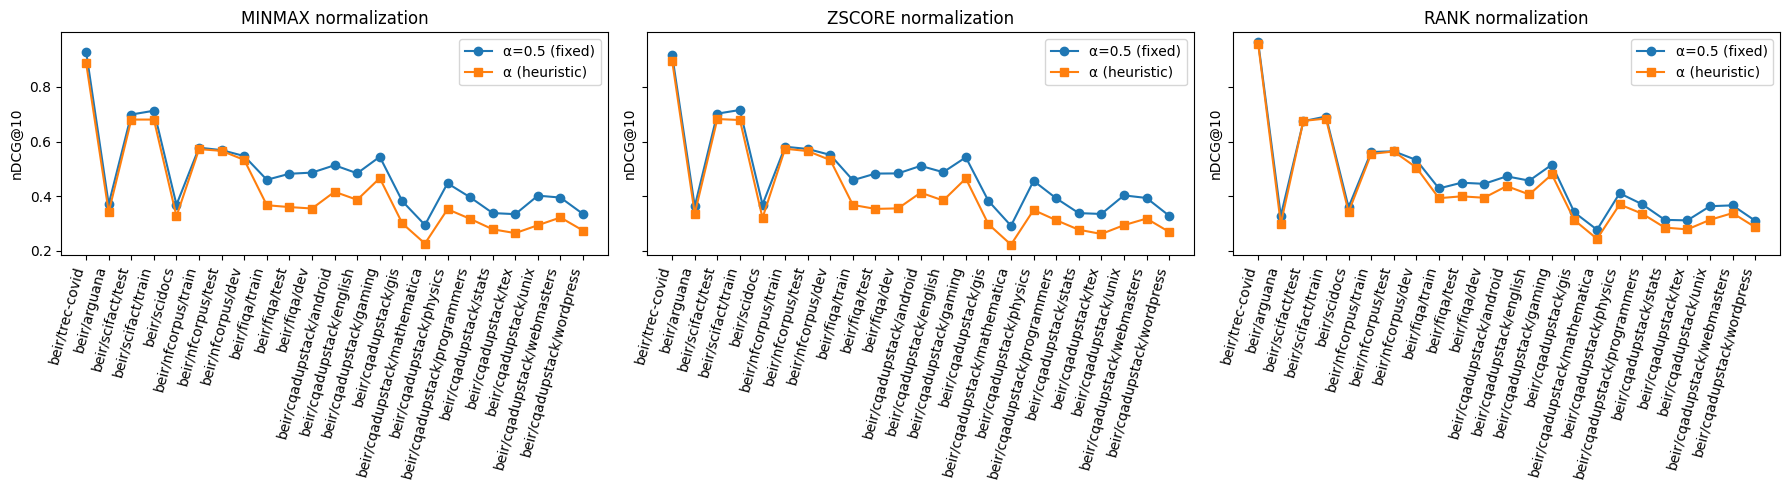

In [1]:
# ================================================
# 📘 Hybrid Evaluation Across Multiple Datasets
# ================================================
import ir_datasets, os, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict, Counter

# -------------------------------
# CONFIG
# -------------------------------
DATASETS = [
    "beir/trec-covid","beir/arguana","beir/scifact/test","beir/scifact/train","beir/scidocs",
    "beir/nfcorpus/train","beir/nfcorpus/test","beir/nfcorpus/dev","beir/fiqa/train",
    "beir/fiqa/test","beir/fiqa/dev","beir/cqadupstack/android","beir/cqadupstack/english",
    "beir/cqadupstack/gaming","beir/cqadupstack/gis","beir/cqadupstack/mathematica",
    "beir/cqadupstack/physics","beir/cqadupstack/programmers","beir/cqadupstack/stats",
    "beir/cqadupstack/tex","beir/cqadupstack/unix","beir/cqadupstack/webmasters",
    "beir/cqadupstack/wordpress"
]

RUNS_DIR = "./runs"
TOP_K = 100
EVAL_K = 10

# -------------------------------
# METRICS
# -------------------------------
def ndcg_at_k(run, qrels, k=10):
    def dcg(rels): return sum(rel / math.log2(i + 2) for i, rel in enumerate(rels))
    vals = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        idcg = dcg(sorted(rels, reverse=True))
        vals.append((dcg(rels)/idcg) if idcg > 0 else 0.0)
    return float(np.mean(vals)) if vals else 0.0


# -------------------------------
# READ TREC
# -------------------------------
def read_trec(path):
    per_q = defaultdict(list)
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6: continue
            qid, _, docid, _rank, score, _sys = parts[:6]
            per_q[qid].append((docid, float(score)))
    for qid in per_q:
        per_q[qid].sort(key=lambda x: x[1], reverse=True)
    return per_q


# -------------------------------
# NORMALIZATIONS
# -------------------------------
def minmax_norm(scores):
    if not scores: return {}
    vals = np.array([s for _, s in scores])
    lo, hi = vals.min(), vals.max()
    if hi <= lo: return {d: 0.0 for d,_ in scores}
    return {d: (s-lo)/(hi-lo) for d,s in scores}

def zscore_norm(scores):
    if not scores: return {}
    vals = np.array([s for _, s in scores])
    mu, sigma = vals.mean(), vals.std() + 1e-9
    return {d: (s-mu)/sigma for d,s in scores}

def rank_norm(scores):
    n=len(scores)
    if n==0: return {}
    sorted_scores = sorted(scores, key=lambda x:x[1], reverse=True)
    return {doc: (n-r)/max(1,n-1) for r,(doc,_) in enumerate(sorted_scores,1)}


# -------------------------------
# FUSION
# -------------------------------
def fuse_per_query(qid, bm25, dense, norm, alpha, topk=TOP_K):
    b, d = bm25.get(qid, []), dense.get(qid, [])
    if norm=="minmax": bn, dn = minmax_norm(b), minmax_norm(d)
    elif norm=="zscore": bn, dn = zscore_norm(b), zscore_norm(d)
    else: bn, dn = rank_norm(b), rank_norm(d)
    cand = set([doc for doc,_ in b]) | set([doc for doc,_ in d])
    fused=[(doc, alpha*bn.get(doc,0.0)+(1-alpha)*dn.get(doc,0.0)) for doc in cand]
    fused.sort(key=lambda x:x[1], reverse=True)
    return fused[:topk]


def build_hybrid_run(bm25, dense, norm, alpha):
    run = defaultdict(list)
    for qid in sorted(set(list(bm25.keys())+list(dense.keys()))):
        run[qid] = fuse_per_query(qid,bm25,dense,norm,alpha)
    return run


# -------------------------------
# HEURISTIC ALPHA (from metadata)
# -------------------------------
def compute_alpha_from_metadata(num_docs,num_queries,num_qrels,rel_counts):
    avg_rels = num_qrels / max(1,num_queries)
    doc_factor = np.clip(np.log10(num_docs)/6,0,1)
    query_factor = np.clip(num_queries/10000,0,1)
    alpha_bm25_bias = 1.0 - 0.5*query_factor - 0.3*doc_factor
    alpha_dense_bias = 1.0 - np.clip(avg_rels/100,0,1)
    alpha = np.clip(0.5*alpha_bm25_bias + 0.5*alpha_dense_bias,0.2,0.8)
    return round(alpha,2)


def get_dataset_metadata(dataset):
    num_docs = sum(1 for _ in dataset.docs_iter())
    num_queries = sum(1 for _ in dataset.queries_iter())
    rel_counts = Counter()
    num_qrels=0
    for r in dataset.qrels_iter():
        num_qrels+=1
        rel_counts[int(r.relevance)]+=1
    return num_docs,num_queries,num_qrels,dict(rel_counts)


# -------------------------------
# MAIN LOOP
# -------------------------------
results=[]
for DATASET_NAME in DATASETS:
    print(f"\n🔹 Evaluating {DATASET_NAME}")
    dataset = ir_datasets.load(DATASET_NAME)
    qrels={}
    for r in dataset.qrels_iter():
        qrels.setdefault(str(r.query_id),{})[str(r.doc_id)]=int(r.relevance)
    num_docs,num_queries,num_qrels,rel_counts = get_dataset_metadata(dataset)
    heuristic_alpha = compute_alpha_from_metadata(num_docs,num_queries,num_qrels,rel_counts)
    
    bm25_path = os.path.join(RUNS_DIR,f"run_bm25_{DATASET_NAME.replace('/','_')}.trec")
    dense_path = os.path.join(RUNS_DIR,f"run_dense_{DATASET_NAME.replace('/','_')}.trec")
    if not (os.path.exists(bm25_path) and os.path.exists(dense_path)):
        print("⚠️ Missing run files, skipping.")
        continue
    bm25 = read_trec(bm25_path)
    dense = read_trec(dense_path)
    
    for norm in ["minmax","zscore","rank"]:
        # fixed α = 0.5
        run_fixed = build_hybrid_run(bm25,dense,norm,alpha=0.5)
        score_fixed = ndcg_at_k(run_fixed,qrels,k=EVAL_K)
        # heuristic α
        run_heur = build_hybrid_run(bm25,dense,norm,alpha=heuristic_alpha)
        score_heur = ndcg_at_k(run_heur,qrels,k=EVAL_K)
        
        results.append({
            "dataset":DATASET_NAME,
            "norm":norm,
            "alpha_fixed":0.5,
            "alpha_heur":heuristic_alpha,
            "score_fixed":score_fixed,
            "score_heur":score_heur
        })
        print(f"{norm:<8} | α=0.5: {score_fixed:.4f} | α={heuristic_alpha:.2f}: {score_heur:.4f}")

df=pd.DataFrame(results)

# -------------------------------
# PLOT
# -------------------------------
fig, axes = plt.subplots(1,3,figsize=(18,5),sharey=True)
for i,norm in enumerate(["minmax","zscore","rank"]):
    subset=df[df["norm"]==norm]
    axes[i].plot(subset["dataset"],subset["score_fixed"],marker="o",label="α=0.5 (fixed)")
    axes[i].plot(subset["dataset"],subset["score_heur"],marker="s",label="α (heuristic)")
    axes[i].set_title(f"{norm.upper()} normalization")
    axes[i].set_ylabel("nDCG@10")
    axes[i].set_xticklabels(subset["dataset"],rotation=75,ha='right')
    axes[i].legend()
plt.tight_layout()
plt.show()
